In [5]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike
from utils.capsule_migration import capsule_directories, CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df
from utils.lick_utils import load_licks, load_licks_video
from ani_session_processing.antidromic_analysis_session import plot_opto_responses
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
import statsmodels.api as sm
from aind_ephys_utils import align
import k3d
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()

%matplotlib inline

In [6]:
examples = [('behavior_751766_2025-02-14_11-37-11', ['FigureS12c_bottom']),
            ('behavior_ZS062_2021-04-30_18-11-39', ['FigureS12b', 'FigureS12c_top'])]

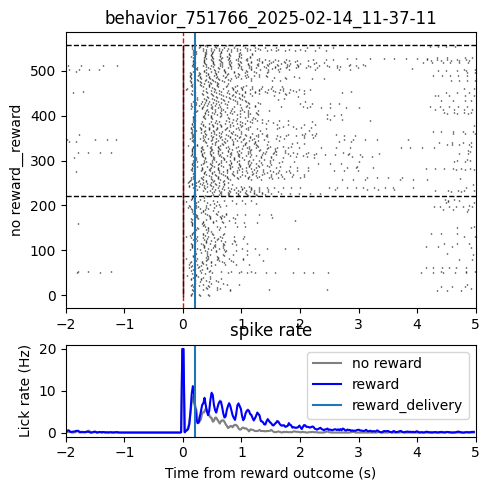

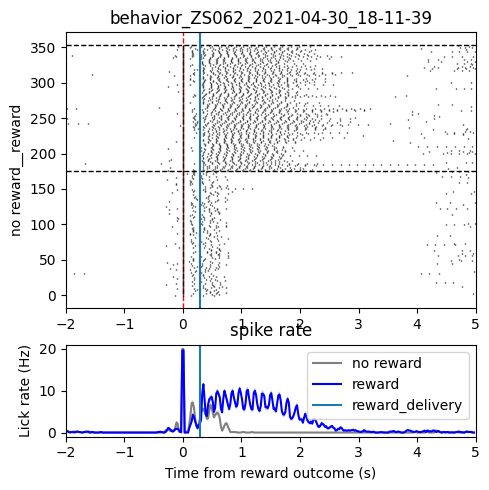

In [7]:
target_folder = f'{capsule_dirs["manuscript_fig_dir"]}/F_example_licks'
os.makedirs(target_folder, exist_ok=True)

color_map = LinearSegmentedColormap.from_list('rew_cmap', ['gray', 'blue'])
bins = [0, 1, 2]  # no-reward: [0,1);  reward: [1,2)
labels = ['no reward', 'reward']
tb, tf = -2, 5
time_bin = 0.05 
step_size = 0.02

for session_id, panels in examples:
    # licks (concatenated across left/right, sorted)
    licks = load_licks(session_id)
    licks_all = np.sort(np.concatenate([licks['licks_L_cleaned'], licks['licks_R_cleaned']]))

    # trial info
    session_tbl = get_session_tbl(session_id)
    session_tbl = session_tbl[session_tbl['animal_response']!=2]
    align_events = session_tbl['reward_outcome_time'].values
    rewarded = (session_tbl['rewarded_historyL'].astype(bool) |
                session_tbl['rewarded_historyR'].astype(bool)).values.astype(int)
    reward_delay = np.mean(session_tbl['reward_delay'].values)

    # figure
    fig = plt.figure(figsize=(5, 5))
    gs = gridspec.GridSpec(1, 1)
    fig, ax1, ax2 = plot_raster_rate(
        licks_all,
        align_events,
        rewarded,
        bins,
        labels,
        color_map,
        fig,
        gs[0],
        tb=tb,
        tf=tf,
        time_bin=time_bin,
        step_size=step_size,
    )
    ax1.set_title(f'{session_id}')
    ax1.axvline(reward_delay, label = 'reward_delivery')
    ax2.set_ylabel('Lick rate (Hz)')
    ax2.axvline(reward_delay, label = 'reward_delivery')
    ax2.legend()
    ax2.set_xlabel('Time from reward outcome (s)')
    plt.tight_layout()

    # save figure once per panel
    name = f'licks_reward_{session_id}'
    save_panels(fig, target_folder, name, panels, exts=('pdf',), bbox_inches='tight')

    # raster CSV: one row per lick, columns = trial_index, rewarded, lick_time (rel to alignment)
    sort_ind = np.argsort(rewarded)
    sorted_events = align_events[sort_ind]
    sorted_rewarded = rewarded[sort_ind]
    raster_rows = []
    for trial_rank, (t0, rew) in enumerate(zip(sorted_events, sorted_rewarded)):
        rel = licks_all[(licks_all >= t0 + tb) & (licks_all <= t0 + tf)] - t0
        for lt in rel:
            raster_rows.append({'trial_sorted': trial_rank, 'rewarded': int(rew), 'lick_time': lt})
    raster_df = pd.DataFrame(raster_rows)
    save_panel_csv(raster_df, target_folder, name, panels, plot_type='raster')

    # rate CSV: time bins x conditions (mean +/- sem)
    rate_mat, slide_times = get_spike_matrix(
        licks_all, align_events,
        pre_event=tb, post_event=tf,
        binSize=time_bin, stepSize=step_size,
        kernel=False, avoid_overlap=True,
    )
    rate_cols = {'time': slide_times}
    for bin_ind, lab in enumerate(labels):
        sel = np.where((rewarded >= bins[bin_ind]) & (rewarded < bins[bin_ind + 1]))[0]
        if len(sel):
            m = rate_mat[sel, :]
            rate_cols[f'{lab}_mean'] = np.nanmean(m, axis=0)
            rate_cols[f'{lab}_sem'] = np.nanstd(m, axis=0) / np.sqrt(m.shape[0])
    save_panel_csv(columns_to_df(**rate_cols), target_folder, name, panels, plot_type='mean_rate')

    plt.show()

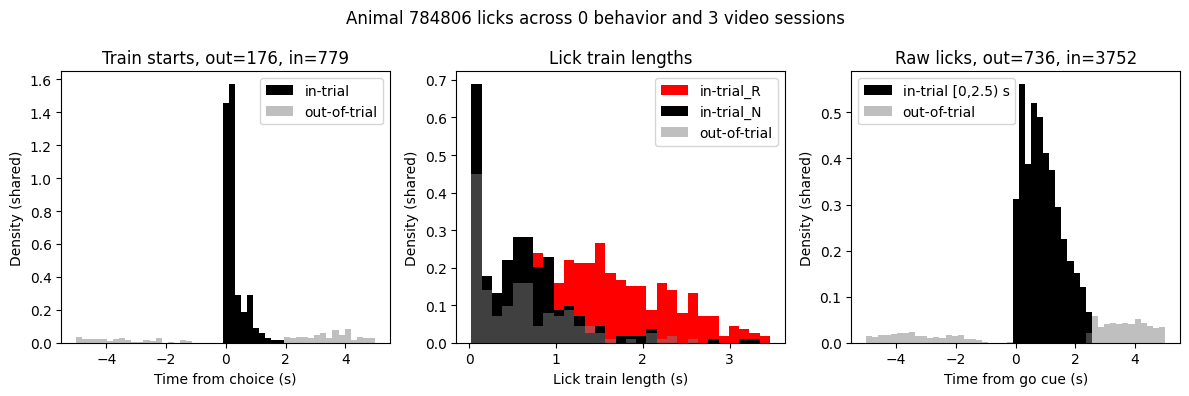

In [10]:
# Regenerate lick_trains_video_True.pdf: per-animal histograms
# using video-detected licks (with behavioral-lick fallback when video unavailable).
# Source: figure_preparation/licks_prep.py `analyze_animal_licks(..., video=True)`,
# the `if plot:` histogram block.
# Left:   lick-train start times aligned to go cue, in-trial vs out-of-trial (train-level)
# Middle: lick-train lengths, in-trial rewarded / in-trial no-reward / out-of-trial
# Right:  raw lick times aligned to go cue, in-trial (0-2 s after go cue) vs out-of-trial

def plot_lick_trains_hist(animal_id, sessions, tb=-5, tf=5, in_trial_win=(0, 2.5), inter_train_interval=1000):
    # lick-train aggregates
    aligned_licks = []
    in_out_mask = []
    lick_len = []
    rewarded_licks = []
    # raw-lick aggregates
    aligned_raw = []
    in_out_raw = []
    used_sessions = []
    video_sessions = 0
    beh_sessions = 0

    for sess in sessions:
        session_tbl = get_session_tbl(sess)
        if session_tbl is None:
            continue
        licks = load_licks_video(sess, plot=False, inter_train_interval=inter_train_interval)
        if licks is None:
            print(f'{sess} has no video data, loading behavioral licks instead')
            licks = load_licks(sess, plot=False, inter_train_interval=inter_train_interval)
            beh_sessions += 1
        else:
            video_sessions += 1
        all_licks = licks['lick_trains_all']['train_starts']
        in_trial_session = licks['lick_trains_all']['in_trial']
        lick_len_session = licks['lick_trains_all']['train_ends'] - licks['lick_trains_all']['train_starts']
        # Guard: some sessions have a length mismatch between in_trial and train_starts.
        # Trim to the shortest so masking still works.
        _n = min(len(all_licks), len(in_trial_session), len(lick_len_session))
        all_licks = all_licks[:_n]
        in_trial_session = in_trial_session[:_n]
        lick_len_session = lick_len_session[:_n]
        all_licks_raw = np.sort(np.concatenate([licks['licks_L_cleaned'], licks['licks_R_cleaned']]))

        for idx, row in session_tbl.iterrows():
            t0 = row['goCue_start_time']
            # lick-train contributions
            mask = (all_licks >= t0 + tb) & (all_licks <= t0 + tf)
            if idx < (len(session_tbl) - 1):
                mask &= (all_licks < session_tbl.iloc[idx + 1]['goCue_start_time'] + tb)
            if idx > 0:
                mask &= (all_licks > session_tbl.iloc[idx - 1]['goCue_start_time'] + tf)
            trial_aligned = list(all_licks[mask] - t0)
            trial_in_out = list(in_trial_session[mask])
            trial_lens = list(lick_len_session[mask])
            aligned_licks.extend(trial_aligned)
            in_out_mask.extend(trial_in_out)
            lick_len.extend(trial_lens)
            if len(trial_aligned) > 0:
                rew_trial = np.zeros(len(trial_aligned), dtype=bool)
                if row['rewarded_historyR'] or row['rewarded_historyL']:
                    rew_trial[np.array(trial_in_out, dtype=bool)] = True
                rewarded_licks.extend(list(rew_trial))

            # raw-lick contributions: same trial-boundary masking, in-trial iff time ∈ [0, 2]
            mask_raw = (all_licks_raw >= t0 + tb) & (all_licks_raw <= t0 + tf)
            if idx < (len(session_tbl) - 1):
                mask_raw &= (all_licks_raw < session_tbl.iloc[idx + 1]['goCue_start_time'] + tb)
            if idx > 0:
                mask_raw &= (all_licks_raw > session_tbl.iloc[idx - 1]['goCue_start_time'] + tf)
            raw_rel = all_licks_raw[mask_raw] - t0
            aligned_raw.extend(list(raw_rel))
            in_out_raw.extend(list((raw_rel >= in_trial_win[0]) & (raw_rel < in_trial_win[1])))

        used_sessions.append(sess)

    aligned_licks = np.array(aligned_licks)
    in_out_mask = np.array(in_out_mask, dtype=bool)
    lick_len = np.array(lick_len)
    rewarded_licks = np.array(rewarded_licks, dtype=bool)
    aligned_raw = np.array(aligned_raw)
    in_out_raw = np.array(in_out_raw, dtype=bool)

    fig = plt.figure(figsize=(12, 4))
    gs = gridspec.GridSpec(1, 3)

    # Panel 1: aligned lick-train starts (shared normalization).
    ax1 = fig.add_subplot(gs[0, 0])
    edges = np.linspace(tb, tf, 50)
    bin_width = edges[1] - edges[0]
    n_total = len(aligned_licks)
    shared_w = np.full(n_total, 1.0 / (n_total * bin_width))
    ax1.hist(aligned_licks[in_out_mask], bins=edges, weights=shared_w[in_out_mask], color='k', label='in-trial')
    ax1.hist(aligned_licks[~in_out_mask], bins=edges, weights=shared_w[~in_out_mask], alpha=0.5, color='gray', label='out-of-trial')
    ax1.set_title(f'Train starts, out={np.sum(~in_out_mask)}, in={np.sum(in_out_mask)}')
    ax1.set_xlabel('Time from choice (s)')
    ax1.set_ylabel('Density (shared)')
    ax1.legend()

    # Panel 2: lick-train lengths (shared normalization across 3 conditions).
    ax2 = fig.add_subplot(gs[0, 1])
    edges_len = np.linspace(np.min(lick_len), np.max(lick_len), 30)
    bin_width_len = edges_len[1] - edges_len[0]
    n_total_len = len(lick_len)
    shared_w_len = np.full(n_total_len, 1.0 / (n_total_len * bin_width_len))
    m_in_r = in_out_mask & rewarded_licks
    m_in_n = in_out_mask & ~rewarded_licks
    m_out = ~in_out_mask
    ax2.hist(lick_len[m_in_r], bins=edges_len, weights=shared_w_len[m_in_r], color='r', label='in-trial_R')
    ax2.hist(lick_len[m_in_n], bins=edges_len, weights=shared_w_len[m_in_n], color='k', label='in-trial_N')
    ax2.hist(lick_len[m_out], bins=edges_len, weights=shared_w_len[m_out], alpha=0.5, color='gray', label='out-of-trial')
    ax2.set_title('Lick train lengths')
    ax2.set_xlabel('Lick train length (s)')
    ax2.set_ylabel('Density (shared)')
    ax2.legend()

    # Panel 3: raw lick times (shared normalization); in-trial = 0-2 s after go cue.
    ax3 = fig.add_subplot(gs[0, 2])
    edges_raw = np.linspace(tb, tf, 50)
    bin_width_raw = edges_raw[1] - edges_raw[0]
    n_total_raw = len(aligned_raw)
    shared_w_raw = np.full(n_total_raw, 1.0 / (n_total_raw * bin_width_raw))
    ax3.hist(aligned_raw[in_out_raw], bins=edges_raw, weights=shared_w_raw[in_out_raw], color='k', label=f'in-trial [{in_trial_win[0]},{in_trial_win[1]}) s')
    ax3.hist(aligned_raw[~in_out_raw], bins=edges_raw, weights=shared_w_raw[~in_out_raw], alpha=0.5, color='gray', label='out-of-trial')
    ax3.set_title(f'Raw licks, out={np.sum(~in_out_raw)}, in={np.sum(in_out_raw)}')
    ax3.set_xlabel('Time from go cue (s)')
    ax3.set_ylabel('Density (shared)')
    ax3.legend()

    plt.suptitle(f'Animal {animal_id} licks across {beh_sessions} behavior and {video_sessions} video sessions')
    plt.tight_layout()
    return fig, {
        'aligned_licks': aligned_licks,
        'in_out_mask': in_out_mask,
        'lick_len': lick_len,
        'rewarded_licks': rewarded_licks,
        'aligned_raw': aligned_raw,
        'in_out_raw': in_out_raw,
    }


# animal id → manuscript panel(s)
animal_panels = [('784806', ['FigureS12g_bottom'])]

_dfs = [pd.read_csv(CAPSULE_ROOT + '/code/data_management/session_assets.csv'),
        pd.read_csv(CAPSULE_ROOT + '/code/data_management/hopkins_session_assets.csv'),
        pd.read_csv(CAPSULE_ROOT + '/code/data_management/hopkins_FP_session_assets.csv')]
_session_df = pd.concat(_dfs)
_session_ids = [s for s in _session_df['session_id'].values.tolist() if str(s).startswith('behavior')]

for animal_id, panels in animal_panels:
    ani_sessions = [s for s in _session_ids if str(s).split('_')[1] == animal_id]
    fig, data = plot_lick_trains_hist(animal_id, ani_sessions)

    name = f'lick_trains_hist_video_{animal_id}'
    save_panels(fig, target_folder, name, panels, exts=('pdf',), bbox_inches='tight')
    save_panel_csv(
        columns_to_df(
            aligned_lick_time=data['aligned_licks'],
            in_trial=data['in_out_mask'].astype(int),
            rewarded=data['rewarded_licks'].astype(int),
            lick_train_length=data['lick_len'],
        ),
        target_folder, name, panels, plot_type='trains',
    )
    save_panel_csv(
        columns_to_df(
            aligned_raw_lick_time=data['aligned_raw'],
            in_trial=data['in_out_raw'].astype(int),
        ),
        target_folder, name, panels, plot_type='raw',
    )
    plt.show()